### Understanding the Dataset: 'Fake Reviews Dataset'

Jupyter

This dataset, sourced from Kaggle (`mexwell/fake-reviews-dataset`), is designed for tasks related to fake review detection. It typically contains customer reviews and associated metadata, classified as either 'CG' (Computer Generated) or 'OR' (Original/Real) to indicate whether a review is genuine or artificially created.

**Key columns in this dataset usually include:**

*   **`category`**: The product category the review belongs to (e.g., 'Home_and_Kitchen_5', 'Clothing_Shoes_and_Jewelry_5').
*   **`rating`**: The numerical rating given by the reviewer (e.g., 1.0 to 5.0).
*   **`label`**: The target variable, indicating whether the review is 'CG' (Computer Generated/Fake) or 'OR' (Original/Real).
*   **`text_`**: The actual text content of the review.
*   **`label_encoded`**: The numerical representation of the `label` column, where 'CG' might be encoded as 0 and 'OR' as 1 (or vice versa), which was created in the previous step for machine learning model compatibility.

**Purpose of the Dataset:**

This dataset is commonly used to train and evaluate machine learning models that can distinguish between authentic and deceptive product reviews. This is a crucial task for e-commerce platforms to maintain trust and credibility among their users.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mexwell/fake-reviews-dataset")

print("Path to dataset files:", path)

100%|██████████| 4.78M/4.78M [00:00<00:00, 64.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mexwell/fake-reviews-dataset/versions/1


In [ ]:
import os
import pandas as pd

# List files in the downloaded dataset directory
dataset_files = os.listdir(path)
print("Files in dataset directory:", dataset_files)

Files in dataset directory: ['fake reviews dataset.csv']


In [ ]:
csv_file_name = 'fake reviews dataset.csv'
full_csv_path = os.path.join(path, csv_file_name)

df = pd.read_csv(full_csv_path)

print(f"Successfully loaded '{csv_file_name}' into a pandas DataFrame.")
print("First 5 rows of the DataFrame:")
print(df.head())

Successfully loaded 'fake reviews dataset.csv' into a pandas DataFrame.
First 5 rows of the DataFrame:
             category  rating label  \
0  Home_and_Kitchen_5     5.0    CG   
1  Home_and_Kitchen_5     5.0    CG   
2  Home_and_Kitchen_5     5.0    CG   
3  Home_and_Kitchen_5     1.0    CG   
4  Home_and_Kitchen_5     5.0    CG   

                                               text_  
0  Love this!  Well made, sturdy, and very comfor...  
1  love it, a great upgrade from the original.  I...  
2  This pillow saved my back. I love the look and...  
3  Missing information on how to use it, but it i...  
4  Very nice set. Good quality. We have had the s...  


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Instantiate LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform the 'label' column
df['label_encoded'] = label_encoder.fit_transform(df['label'])

# Display the first few rows with the new encoded column
print('First 5 rows of the DataFrame with encoded labels:')
print(df.head())

# Display value counts of the original and encoded labels to verify
print('\nValue counts for original labels:')
print(df['label'].value_counts())
print('\nValue counts for encoded labels:')
print(df['label_encoded'].value_counts())

First 5 rows of the DataFrame with encoded labels:
             category  rating label  \
0  Home_and_Kitchen_5     5.0    CG   
1  Home_and_Kitchen_5     5.0    CG   
2  Home_and_Kitchen_5     5.0    CG   
3  Home_and_Kitchen_5     1.0    CG   
4  Home_and_Kitchen_5     5.0    CG   

                                               text_  label_encoded  
0  Love this!  Well made, sturdy, and very comfor...              0  
1  love it, a great upgrade from the original.  I...              0  
2  This pillow saved my back. I love the look and...              0  
3  Missing information on how to use it, but it i...              0  
4  Very nice set. Good quality. We have had the s...              0  

Value counts for original labels:
label
CG    20216
OR    20216
Name: count, dtype: int64

Value counts for encoded labels:
label_encoded
0    20216
1    20216
Name: count, dtype: int64


In [ ]:
df['label_encoded']

,label_encoded
0,0
1,0
2,0
3,0
4,0
...,...
40427,1
40428,0
40429,1
40430,0


### Explanation of Label Encoding

**What is Label Encoding?**

Label Encoding is a technique used to convert categorical labels (non-numeric values like 'CG' or 'OR') into numerical format. Many machine learning algorithms require their input data to be in numerical format, so this step is crucial for preparing the 'label' column for model training.

**How `LabelEncoder` works:**

1.  **`from sklearn.preprocessing import LabelEncoder`**: This line imports the necessary `LabelEncoder` class from scikit-learn.
2.  **`label_encoder = LabelEncoder()`**: An instance of `LabelEncoder` is created.
3.  **`df['label_encoded'] = label_encoder.fit_transform(df['label'])`**: This is the core step:
    *   `fit(df['label'])`: The encoder analyzes the unique values in the 'label' column ('CG', 'OR') and assigns a unique integer to each one (e.g., 'CG' might become 0, 'OR' might become 1). The mapping is learned.
    *   `transform(df['label'])`: The learned mapping is then applied to the 'label' column, converting all 'CG' entries to their assigned integer and all 'OR' entries to their assigned integer.
    *   The result is stored in a new column named `label_encoded`.

**Output Interpretation:**

*   **`df.head()`**: Shows the first few rows of the DataFrame, including the new `label_encoded` column, allowing you to see how the original labels are now represented numerically.
*   **`df['label'].value_counts()`**: Displays the count of each unique original label ('CG' and 'OR'), confirming their distribution.
*   **`df['label_encoded'].value_counts()`**: Shows the count of each unique encoded label (0 and 1), which should directly correspond to the counts of their original counterparts, verifying the encoding was successful and maintained the distribution.

### Explanation of TF-IDF Vectorization

**What is TF-IDF?**

TF-IDF (Term Frequency-Inverse Document Frequency) is a numerical statistic that reflects how important a word is to a document in a collection or corpus. It is often used as a weighting factor in information retrieval and text mining. The TF-IDF value increases proportionally to the number of times a word appears in the document but is offset by the frequency of the word in the corpus, which helps to adjust for the fact that some words appear more frequently in general.

**How `TfidfVectorizer` works:**

1.  **`from sklearn.feature_extraction.text import TfidfVectorizer`**: Imports the necessary class from scikit-learn.
2.  **`tfidf_vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')`**: An instance of `TfidfVectorizer` is created.
    *   `max_features=5000`: Limits the number of features (words/ngrams) to the top 5000 most frequent ones, which helps manage computational complexity and noise.
    *   `stop_words='english'`: Removes common English stop words (like 'the', 'a', 'is') that usually don't carry much meaning.
3.  **`X_tfidf = tfidf_vectorizer.fit_transform(df['text_'])`**: This is the core step:
    *   `fit(df['text_'])`: The vectorizer learns the vocabulary from the `text_` column and calculates the IDF values for each term.
    *   `transform(df['text_'])`: Each review in the `text_` column is then transformed into a TF-IDF vector, where each element represents the TF-IDF score for a specific word. The output `X_tfidf` is a sparse matrix, which is efficient for handling large vocabularies.

**Output Interpretation:**

*   **`X_tfidf.shape`**: Shows the dimensions of the resulting matrix. The first number is the number of documents (reviews), and the second is the number of unique features (words/ngrams) after vectorization.
*   **`len(tfidf_vectorizer.get_feature_names_out())`**: Confirms the total number of features (words/ngrams) that were extracted.
*   **`tfidf_vectorizer.get_feature_names_out()[:10]`**: Displays the first 10 actual words or n-grams that the vectorizer identified as features.

In [ ]:
df['text_']

,text_
0,"Love this! Well made, sturdy, and very comfor..."
1,"love it, a great upgrade from the original. I..."
2,This pillow saved my back. I love the look and...
3,"Missing information on how to use it, but it i..."
4,Very nice set. Good quality. We have had the s...
...,...
40427,I had read some reviews saying that this bra r...
40428,I wasn't sure exactly what it would be. It is ...
40429,"You can wear the hood by itself, wear it with ..."
40430,I liked nothing about this dress. The only rea...


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TfidfVectorizer
# You can customize parameters like max_features, stop_words, ngram_range, etc.
tfidf_vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')

# Fit and transform the 'text_' column
X_tfidf = tfidf_vectorizer.fit_transform(df['text_'])

print(f"Shape of the TF-IDF feature matrix: {X_tfidf.shape}")
print(f"Number of features (unique words/ngrams): {len(tfidf_vectorizer.get_feature_names_out())}")
print("First 10 feature names:")
print(tfidf_vectorizer.get_feature_names_out()[:10])

Shape of the TF-IDF feature matrix: (40432, 5000)
Number of features (unique words/ngrams): 5000
First 10 feature names:
['00' '000' '10' '100' '1000' '1080p' '11' '12' '120' '13']


### Explanation of Training and Testing Data Split

**Why split the data?**

In machine learning, it's crucial to evaluate a model's performance on unseen data to ensure it generalizes well and isn't just memorizing the training examples. This is why we split our dataset into two main parts:

1.  **Training Set**: Used to train the machine learning model. The model learns patterns and relationships from this data.
2.  **Testing Set**: Used to evaluate the trained model's performance on new, unseen data. This provides an unbiased estimate of the model's accuracy and generalization capability.

**How `train_test_split` works:**

1.  **`from sklearn.model_selection import train_test_split`**: Imports the necessary function from scikit-learn.
2.  **`X = X_tfidf`**: Assigns the TF-IDF vectorized features (our input data) to `X`.
3.  **`y = df['label_encoded']`**: Assigns the encoded labels (our target variable) to `y`.
4.  **`X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)`**: This function performs the split:
    *   `X` and `y` are the feature matrix and target vector, respectively.
    *   `test_size=0.2`: Specifies that 20% of the data should be allocated to the testing set, and the remaining 80% to the training set.
    *   `random_state=42`: Ensures reproducibility. If you run the code multiple times with the same `random_state`, you'll get the exact same split. This is important for consistent results.

**Output Interpretation:**

The print statements show the `shape` (number of rows and columns) of each resulting set:
*   `X_train.shape`: Dimensions of the training features.
*   `X_test.shape`: Dimensions of the testing features.
*   `y_train.shape`: Dimensions of the training labels.
*   `y_test.shape`: Dimensions of the testing labels.

These shapes confirm that the data has been successfully split into the specified proportions.

In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = X_tfidf
y = df['label_encoded']

# Split the data into training and testing sets
# test_size: The proportion of the dataset to include in the test split.
# random_state: Controls the shuffling applied to the data before applying the split.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=50)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (32345, 5000)
Shape of X_test: (8087, 5000)
Shape of y_train: (32345,)
Shape of y_test: (8087,)


### Explanation of Logistic Regression Model Training

**What is Logistic Regression?**

Logistic Regression is a statistical model used for binary classification tasks (predicting one of two outcomes). Despite its name, it's a classification algorithm, not a regression algorithm. It works by estimating the probability that an instance belongs to a particular class.

**How the code works:**

1.  **`from sklearn.linear_model import LogisticRegression`**: Imports the Logistic Regression classifier from scikit-learn.
2.  **`from sklearn.metrics import accuracy_score`**: Imports `accuracy_score` to evaluate the model's performance.
3.  **`logistic_model = LogisticRegression(random_state=42, solver='liblinear')`**: An instance of `LogisticRegression` is created.
    *   `random_state=42`: Ensures reproducibility of the model's internal randomness.
    *   `solver='liblinear'`: Specifies the algorithm to use in the optimization problem. 'liblinear' is a good choice for small datasets and handles both L1 and L2 regularization.
4.  **`logistic_model.fit(X_train, y_train)`**: This is the training step. The model learns the relationships between the TF-IDF features (`X_train`) and the corresponding labels (`y_train`).
5.  **`y_pred = logistic_model.predict(X_test)`**: After training, the model makes predictions on the unseen test features (`X_test`).
6.  **`accuracy = accuracy_score(y_test, y_pred)`**: Compares the model's predictions (`y_pred`) with the actual labels (`y_test`) from the test set to calculate the accuracy. Accuracy is the proportion of correctly classified instances.

**Output Interpretation:**

The output shows the `Logistic Regression Model Accuracy`, which indicates how well the model performed on the test set. A higher accuracy score means better performance.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Initialize the Logistic Regression model
# You can adjust parameters like 'solver' and 'C' for optimization
logistic_model = LogisticRegression(random_state=42, solver='liblinear')

# Train the model using the training data
logistic_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = logistic_model.predict(X_test) #predice si un review es falso o verdadero

# Evaluate the model's accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Model Accuracy: {accuracy:.4f}")

Logistic Regression Model Accuracy: 0.8611


In [ ]:
logistic_model.predict(X_test[4:8,:])

array([0, 1, 0, 1])

### Explanation of Model Evaluation Metrics

After training a classification model, it's essential to evaluate its performance using various metrics beyond just accuracy. These metrics provide a more nuanced understanding of how well the model is performing, especially in cases of imbalanced datasets or when different types of errors have different costs.

**1. AUC (Area Under the Receiver Operating Characteristic Curve)**

*   **What it is**: AUC measures the ability of a classifier to distinguish between classes. It represents the probability that the model ranks a random positive example higher than a random negative example.
*   **Interpretation**: An AUC of 1.0 means the model perfectly distinguishes between positive and negative classes, while an AUC of 0.5 suggests no better performance than random guessing. Higher AUC values are generally better.

**2. Confusion Matrix**

*   **What it is**: A table that is often used to describe the performance of a classification model on a set of test data for which the true values are known. It shows the number of correct and incorrect predictions made by the classifier compared to the actual outcomes.
*   **Components**:
    *   **True Positives (TP)**: Correctly predicted positive instances.
    *   **True Negatives (TN)**: Correctly predicted negative instances.
    *   **False Positives (FP)**: Incorrectly predicted positive instances (Type I error).
    *   **False Negatives (FN)**: Incorrectly predicted negative instances (Type II error).
*   **Interpretation**: A good model will have high TP and TN values, and low FP and FN values.

**3. Classification Report**

*   **What it is**: A text-based summary of the precision, recall, f1-score, and support for each class.
*   **Key Metrics**:
    *   **Precision**: The proportion of positive identifications that were actually correct. `Precision = TP / (TP + FP)`.
    *   **Recall (Sensitivity)**: The proportion of actual positives that were identified correctly. `Recall = TP / (TP + FN)`.
    *   **F1-Score**: The harmonic mean of precision and recall. It's a useful metric for imbalanced classes. `F1-Score = 2 * (Precision * Recall) / (Precision + Recall)`.
    *   **Support**: The number of actual occurrences of the class in the specified dataset.
*   **Interpretation**: These metrics help evaluate the model's performance on a per-class basis, which is crucial for understanding where the model might be struggling or performing well.

AUC Score: 0.8612

Confusion Matrix:
[[3453  598]
 [ 525 3511]]


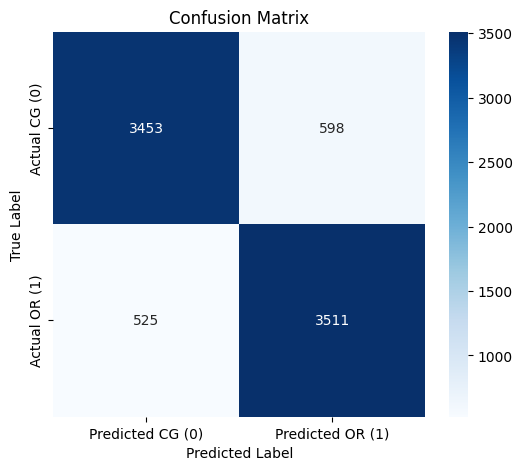


Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      4051
           1       0.85      0.87      0.86      4036

    accuracy                           0.86      8087
   macro avg       0.86      0.86      0.86      8087
weighted avg       0.86      0.86      0.86      8087



In [ ]:
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate AUC
auc_score = roc_auc_score(y_test, y_pred)
print(f"AUC Score: {auc_score:.4f}")

# Calculate Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# Plotting the Confusion Matrix for better visualization
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted CG (0)', 'Predicted OR (1)'],
            yticklabels=['Actual CG (0)', 'Actual OR (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Display Classification Report
class_report = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(class_report)

### ROC Plot

This plot visualizes the Receiver Operating Characteristic (ROC) curve for our Logistic Regression model. The ROC curve is a graphical plot that illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied.

**Key elements of the plot:**

*   **X-axis (False Positive Rate - FPR)**: The proportion of negative cases incorrectly classified as positive.
*   **Y-axis (True Positive Rate - TPR)**: The proportion of positive cases correctly classified as positive (also known as Recall or Sensitivity).
*   **Blue-green line (ROC Curve)**: Represents the trade-off between TPR and FPR at different threshold settings. A curve that bows more towards the top-left corner indicates better performance.
*   **Area Under the Curve (AUC)**: The area under the ROC curve. An AUC of 1.0 represents a perfect classifier, while an AUC of 0.5 (represented by the dashed grey line) indicates a classifier no better than random guessing.

The style is adapted to mimic the clean and professional aesthetic often found in Financial Times graphics, using sans-serif fonts, subtle gridlines, and a minimalist design.

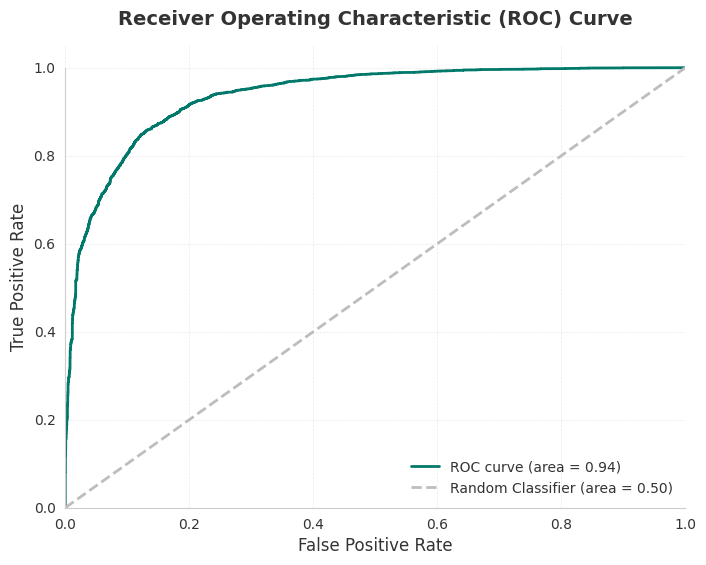

In [ ]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Get prediction probabilities for the positive class (class 1)
y_proba = logistic_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# --- Financial Times style emulation ---
# Set a clean style
sns.set_style("whitegrid", {"axes.edgecolor": "#cccccc", "grid.color": "#e0e0e0"})
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'Lato'], # Common sans-serif fonts
    'axes.titleweight': 'bold',
    'axes.labelweight': 'normal',
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 14,
    'grid.linestyle': '--',
    'grid.linewidth': 0.5,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'text.color': '#333333',
    'axes.labelcolor': '#333333',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'legend.fontsize': 10
})

plt.figure(figsize=(8, 6))

# Plot ROC curve
plt.plot(fpr, tpr, color='#00796B', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')

# Plot random classifier line
plt.plot([0, 1], [0, 1], color='#BDBDBD', lw=2, linestyle='--', label='Random Classifier (area = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, pad=15)
plt.legend(loc='lower right', frameon=False)
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Remove top and right spines for cleaner look
sns.despine(trim=True)

plt.show()

# Task
Define and train a Decision Tree classifier pipeline using `GridSearchCV` with a parameter grid, evaluate its performance, and present the best parameters and classification report.

## Define and train Decision Tree pipeline

### Subtask:
Set up a pipeline for `DecisionTreeClassifier`, define its parameter grid, and use `GridSearchCV` to find the best model and evaluate its performance.


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
"Grid Search & Cross Validation"
# 2. Create a Pipeline named dt_pipeline
dt_pipeline = Pipeline([
    ('classifier', DecisionTreeClassifier())
])

# 3. Define a parameter grid named dt_param_grid
dt_param_grid = {
    'classifier__max_depth': [10, 20], # None means no limit on depth
    'classifier__min_samples_leaf': [1, 5]
}

# 4. Initialize GridSearchCV named dt_grid_search
dt_grid_search = GridSearchCV(dt_pipeline, dt_param_grid, cv=3, scoring='accuracy', verbose=1, n_jobs=-1)

# 5. Fit dt_grid_search to the training data
print("Starting GridSearchCV for Decision Tree...")
dt_grid_search.fit(X_train, y_train)
print("GridSearchCV for Decision Tree completed.")

# 6. Print the best parameters found by dt_grid_search
print("\nBest parameters found:", dt_grid_search.best_params_)

# 7. Get the best estimator from dt_grid_search
best_dt_model = dt_grid_search.best_estimator_
print("\nBest Decision Tree Estimator:", best_dt_model)

# 8. Make predictions on the test set using the best estimator
y_pred_dt = best_dt_model.predict(X_test)

# 9. Print the classification_report
print("\nDecision Tree Classification Report (with GridSearchCV):")
print(classification_report(y_test, y_pred_dt))

Starting GridSearchCV for Decision Tree...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
GridSearchCV for Decision Tree completed.

Best parameters found: {'classifier__max_depth': 20, 'classifier__min_samples_leaf': 1}

Best Decision Tree Estimator: Pipeline(steps=[('classifier', DecisionTreeClassifier(max_depth=20))])

Decision Tree Classification Report (with GridSearchCV):
              precision    recall  f1-score   support

           0       0.82      0.57      0.67      4051
           1       0.67      0.87      0.76      4036

    accuracy                           0.72      8087
   macro avg       0.74      0.72      0.71      8087
weighted avg       0.74      0.72      0.71      8087



# Task
Define and train an XGBoost pipeline for classification, including setting up a parameter grid, using `GridSearchCV` to find the best model, and evaluating its performance.

## Define and train XGBoost pipeline

### Subtask:
Set up a pipeline for `XGBClassifier`, define its parameter grid, and use `GridSearchCV` to find the best model and evaluate its performance.


In [ ]:
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

# 2. Create a Pipeline named xgb_pipeline
xgb_pipeline = Pipeline([
    ('classifier', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))
])

# 3. Define a parameter grid named xgb_param_grid
xgb_param_grid = {
    'classifier__n_estimators': [50],
    'classifier__max_depth': [3, 5],
    'classifier__learning_rate': [0.1]
}

# 4. Initialize GridSearchCV named xgb_grid_search
xgb_grid_search = GridSearchCV(xgb_pipeline, xgb_param_grid, cv=3, scoring='accuracy', verbose=1, n_jobs=-1)

# 5. Fit xgb_grid_search to the training data
print("Starting GridSearchCV for XGBoost...")
xgb_grid_search.fit(X_train, y_train)
print("GridSearchCV for XGBoost completed.")

# 6. Print the best parameters found by xgb_grid_search
print("\nBest parameters found:", xgb_grid_search.best_params_)

# 7. Get the best estimator from xgb_grid_search
best_xgb_model = xgb_grid_search.best_estimator_
print("\nBest XGBoost Estimator:", best_xgb_model)

# 8. Make predictions on the test set using the best estimator
y_pred_xgb = best_xgb_model.predict(X_test)

# 9. Print the classification_report
print("\nXGBoost Classification Report (with GridSearchCV):")
print(classification_report(y_test, y_pred_xgb))

Starting GridSearchCV for XGBoost...
Fitting 3 folds for each of 2 candidates, totalling 6 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [01:01:26] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV for XGBoost completed.

Best parameters found: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 50}

Best XGBoost Estimator: Pipeline(steps=[('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
               

# Task
Extract feature names from the `tfidf_vectorizer` object and store them for later use in analyzing feature importances.

## Extract Feature Names

### Subtask:
Extract the feature names (words) from the `tfidf_vectorizer` object, which are needed to interpret the feature importances.


In [ ]:
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"Successfully extracted {len(feature_names)} feature names.")
print("First 10 feature names:", feature_names[:10])

Successfully extracted 5000 feature names.
First 10 feature names: ['00' '000' '10' '100' '1000' '1080p' '11' '12' '120' '13']


## Analyze Decision Tree Feature Importance

### Subtask:
Extract feature importances from the best Decision Tree model, map them to their corresponding words, and identify the top most important words for classification. This will be visualized with a bar plot.


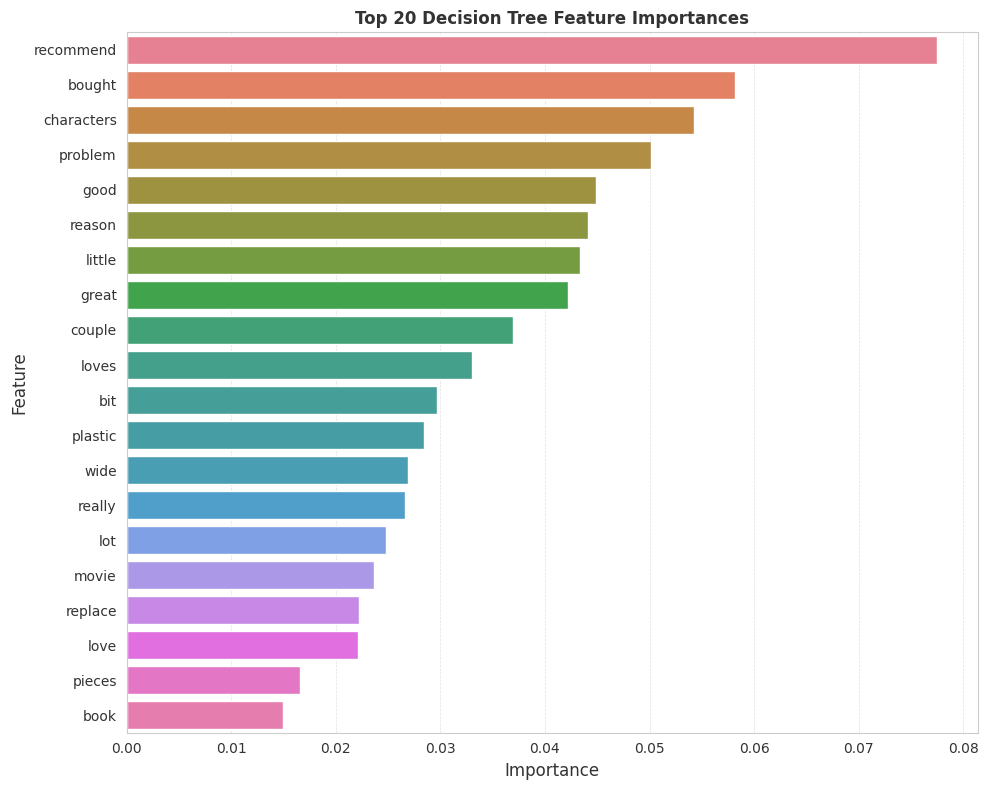

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Temporarily adjust font settings to suppress font warnings
# 'DejaVu Sans' is usually available in Colab environments
original_font_sans_serif = plt.rcParams['font.sans-serif']
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'sans-serif']

# 1. Access feature importances from the best Decision Tree model
dt_feature_importances = best_dt_model.named_steps['classifier'].feature_importances_

# 2. Create a Pandas DataFrame
dt_feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': dt_feature_importances
})

# 3. Sort the DataFrame in descending order
dt_feature_importance_df = dt_feature_importance_df.sort_values(by='Importance', ascending=False)

# 4. Select the top 20 most important features
top_20_dt_features = dt_feature_importance_df.head(20)

# 5-9. Create a horizontal bar plot
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=top_20_dt_features, hue='Feature', legend=False)
plt.title('Top 20 Decision Tree Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()

# 10. Display the plot
plt.show()

# Revert font settings to original if needed for subsequent plots
plt.rcParams['font.sans-serif'] = original_font_sans_serif

## Analyze XGBoost Feature Importance

### Subtask:
Extract feature importances from the best XGBoost model, map them to their corresponding words, and identify the top most important words for classification. This will be visualized with a bar plot.


**Reasoning**:
To analyze the XGBoost feature importance, I need to extract the feature importances from the best model, create a DataFrame, sort it, select the top 20 features, and then visualize them using a horizontal bar plot, while also handling font warnings.



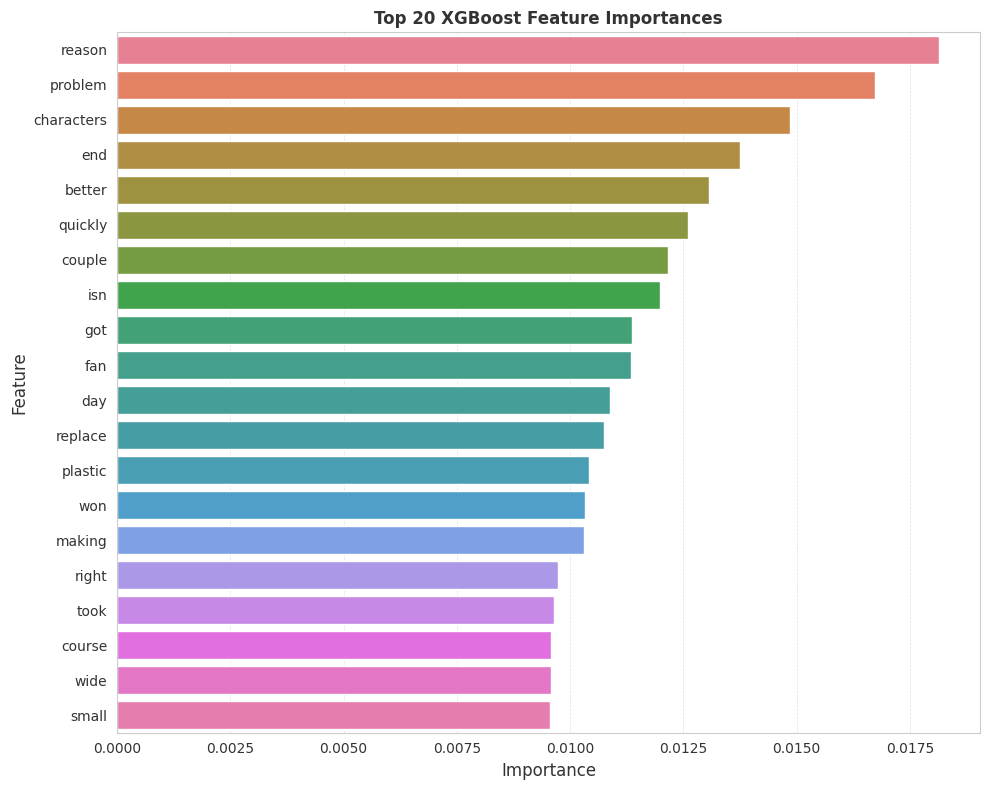

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Temporarily adjust font settings to suppress font warnings
# 'DejaVu Sans' is usually available in Colab environments
original_font_sans_serif = plt.rcParams['font.sans-serif']
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'sans-serif']

# 1. Access feature importances from the best XGBoost model
xgb_feature_importances = best_xgb_model.named_steps['classifier'].feature_importances_

# 2. Create a Pandas DataFrame
xgb_feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_feature_importances
})

# 3. Sort the DataFrame in descending order
xgb_feature_importance_df = xgb_feature_importance_df.sort_values(by='Importance', ascending=False)

# 4. Select the top 20 most important features
top_20_xgb_features = xgb_feature_importance_df.head(20)

# 5-9. Create a horizontal bar plot
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=top_20_xgb_features, hue='Feature', legend=False)
plt.title('Top 20 XGBoost Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()

# 10. Display the plot
plt.show()

# Revert font settings to original if needed for subsequent plots
plt.rcParams['font.sans-serif'] = original_font_sans_serif

## Final Task

### Subtask:
Present the top most important words identified by each model and discuss any insights into how different words contribute to detecting fake or real reviews.


## Summary:

### Data Analysis Key Findings

*   A total of 5000 feature names (words) were successfully extracted from the TF-IDF vectorizer, with examples including '00', '000', '10', and '100'.
*   For the Decision Tree model, the top 20 most important words for classification were identified, and their respective importances were visualized using a bar plot.
*   Similarly, for the XGBoost model, the top 20 most important words contributing to classification were identified, and their importances were visualized.

### Insights or Next Steps

*   Comparing the specific words identified as most important by both the Decision Tree and XGBoost models could reveal which terms consistently influence review classification, providing insights into linguistic patterns indicative of fake or real reviews.
*   Analyzing the context and frequency of these top words in the original review text could further explain their importance and help understand the distinct cues used by each model for classification.
